In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

heart = pd.read_csv(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\Datasets\heart.csv")
heart.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
heart.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
heart.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## UNIVARIATE ANALYSIS

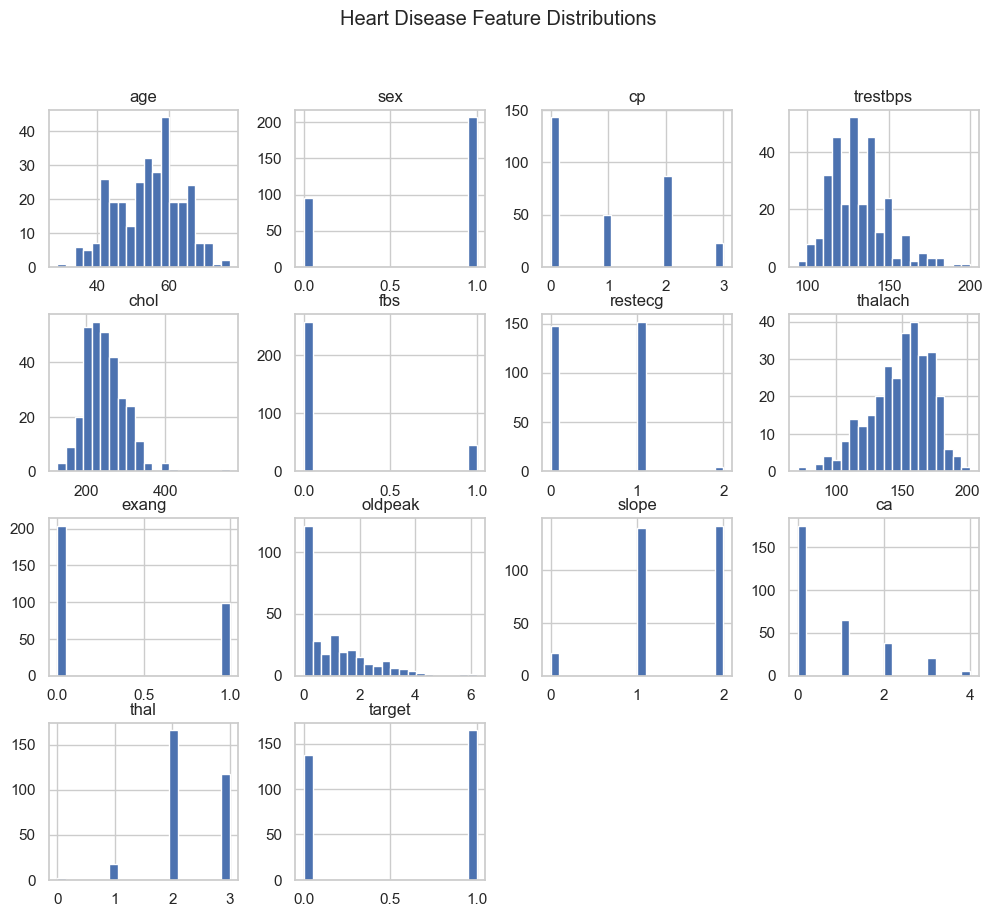

In [10]:
heart.hist(figsize=(12,10), bins=20)
plt.suptitle("Heart Disease Feature Distributions")
plt.show()


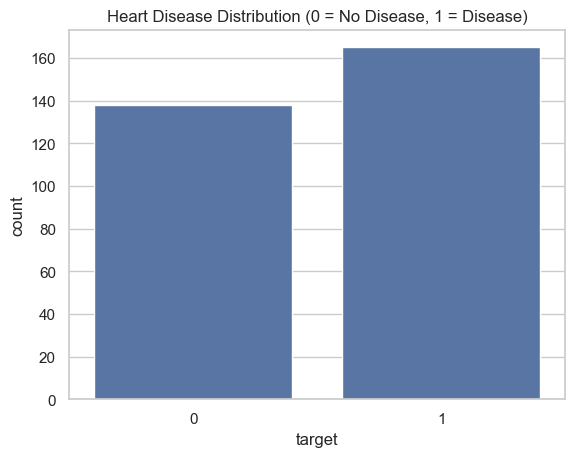

In [11]:
sns.countplot(x='target', data=heart)
plt.title("Heart Disease Distribution (0 = No Disease, 1 = Disease)")
plt.show()


## BIVARIATE ANALYSIS

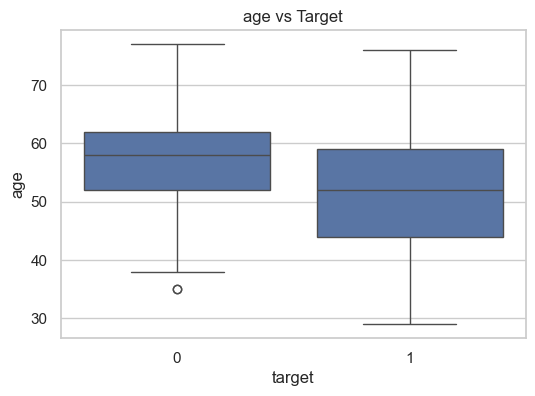

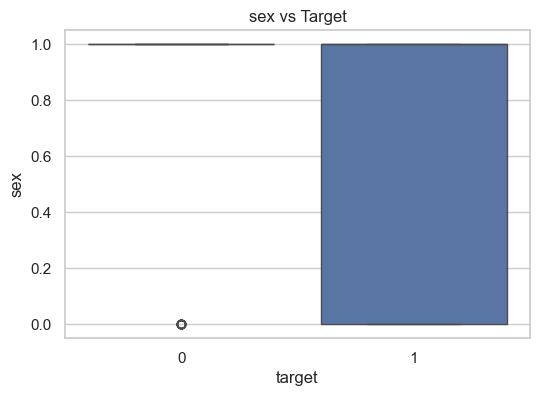

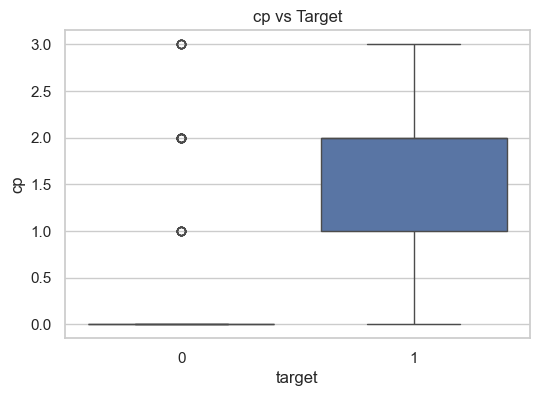

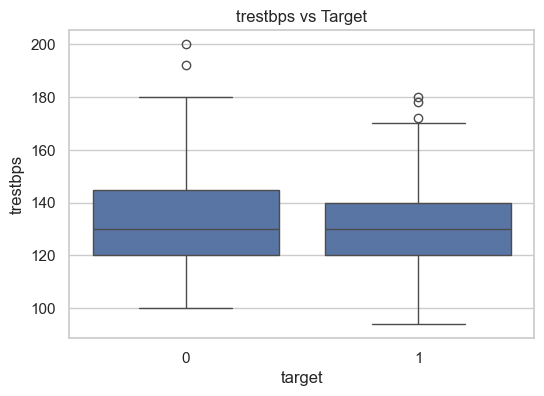

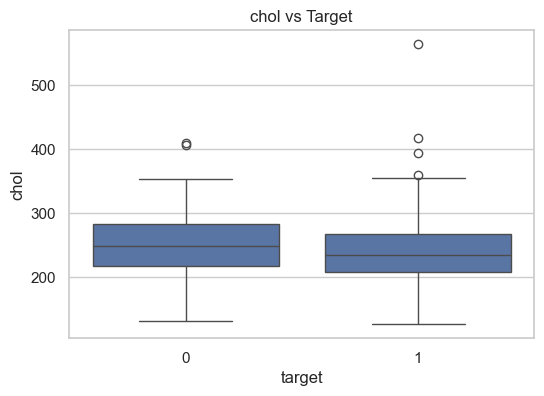

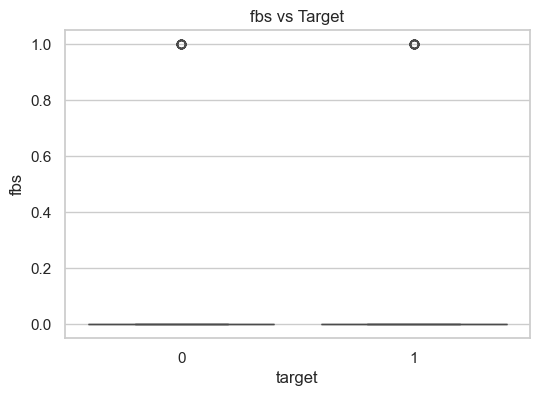

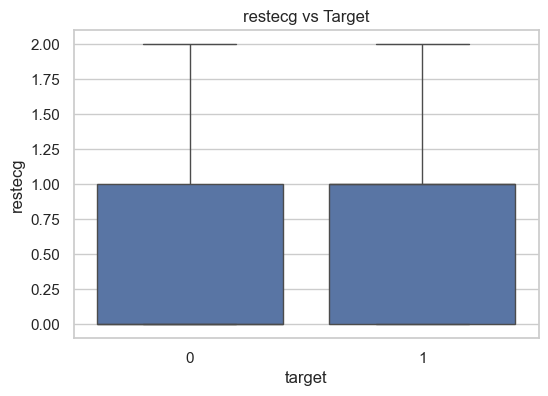

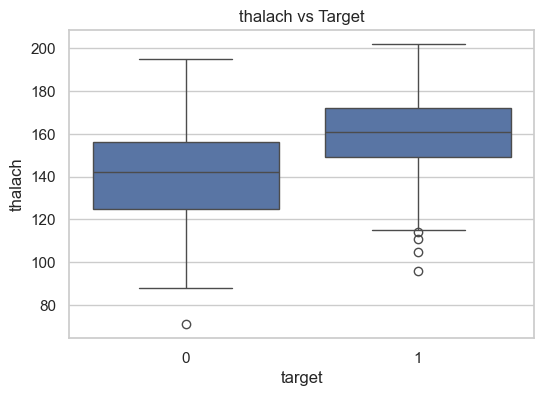

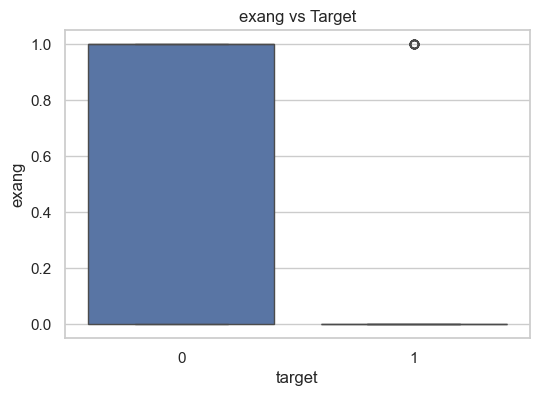

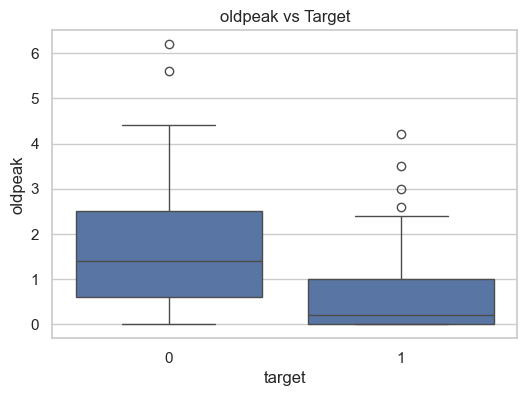

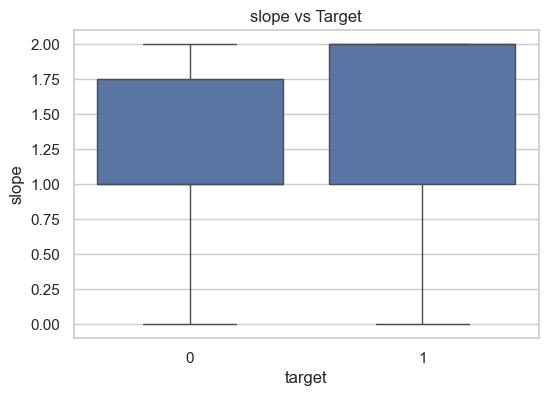

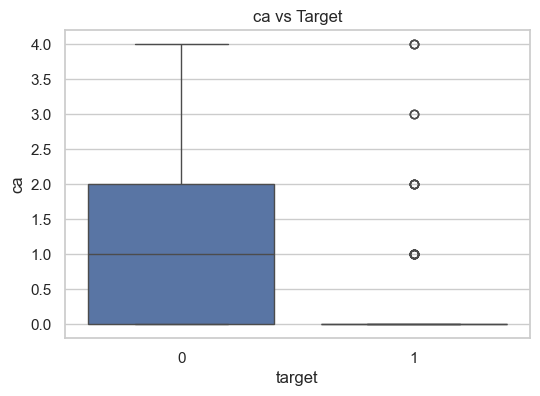

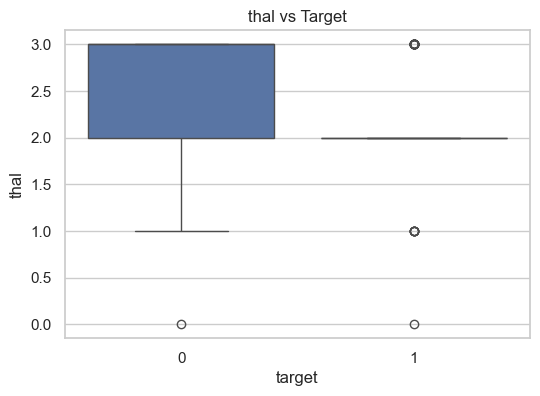

In [15]:
for col in heart.columns:
    if col != 'target':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='target', y=col, data=heart)
        plt.title(f"{col} vs Target")
        plt.show()


## MULTIVARIATE ANALYSIS

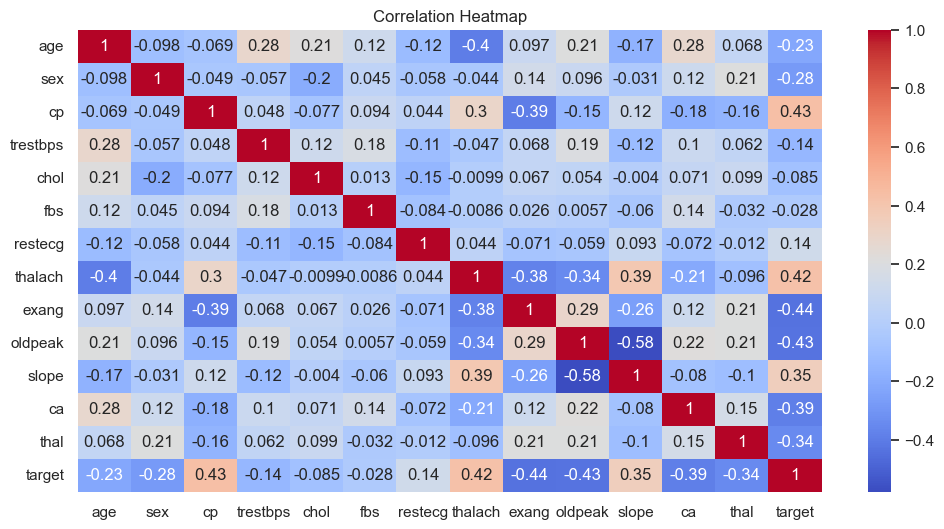

In [18]:
plt.figure(figsize=(12,6))
sns.heatmap(heart.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [20]:
from sklearn.preprocessing import StandardScaler

Xh = heart.drop("target", axis=1)
yh = heart["target"]

scaler_h = StandardScaler()
Xh_scaled = scaler_h.fit_transform(Xh)


In [22]:
from sklearn.model_selection import train_test_split

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh_scaled, yh, test_size=0.2, random_state=42, stratify=yh
)


Logistic Regression Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



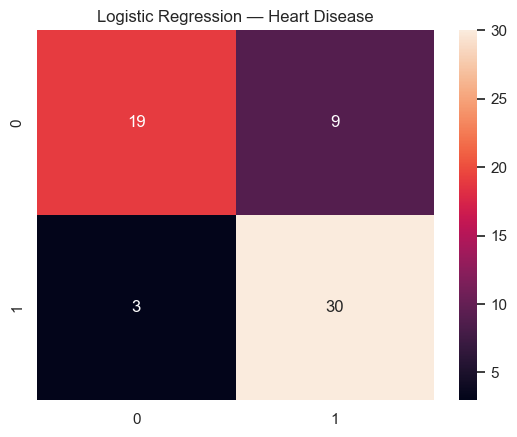

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_h = LogisticRegression(max_iter=500)
log_h.fit(Xh_train, yh_train)

log_pred = log_h.predict(Xh_test)

print("Logistic Regression Accuracy:", accuracy_score(yh_test, log_pred))
print(classification_report(yh_test, log_pred))

sns.heatmap(confusion_matrix(yh_test, log_pred), annot=True, fmt='d')
plt.title("Logistic Regression — Heart Disease")
plt.show()


SVM Accuracy: 0.8360655737704918
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



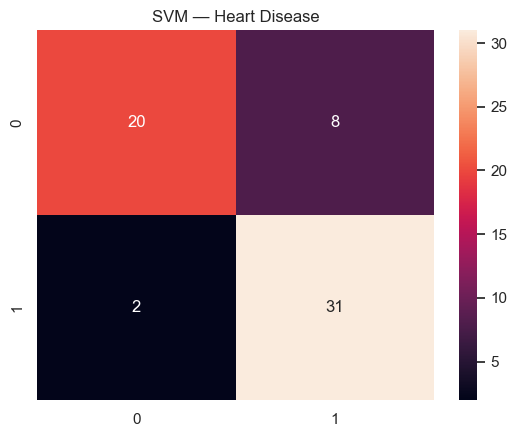

In [26]:
from sklearn.svm import SVC

svm_h = SVC(probability=True)
svm_h.fit(Xh_train, yh_train)

svm_pred = svm_h.predict(Xh_test)

print("SVM Accuracy:", accuracy_score(yh_test, svm_pred))
print(classification_report(yh_test, svm_pred))

sns.heatmap(confusion_matrix(yh_test, svm_pred), annot=True, fmt='d')
plt.title("SVM — Heart Disease")
plt.show()


Random Forest Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



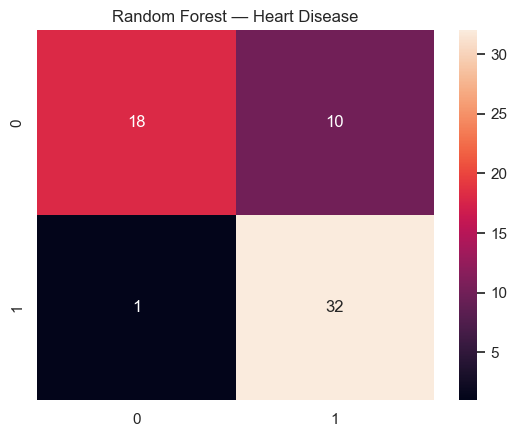

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_h = RandomForestClassifier(n_estimators=300, random_state=42)
rf_h.fit(Xh_train, yh_train)

rf_pred = rf_h.predict(Xh_test)

print("Random Forest Accuracy:", accuracy_score(yh_test, rf_pred))
print(classification_report(yh_test, rf_pred))

sns.heatmap(confusion_matrix(yh_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest — Heart Disease")
plt.show()


XGBoost Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



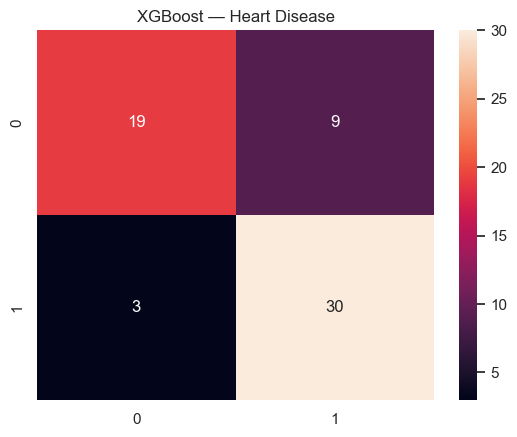

In [30]:
from xgboost import XGBClassifier

xgb_h = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    eval_metric='logloss'
)

xgb_h.fit(Xh_train, yh_train)

xgb_pred = xgb_h.predict(Xh_test)

print("XGBoost Accuracy:", accuracy_score(yh_test, xgb_pred))
print(classification_report(yh_test, xgb_pred))

sns.heatmap(confusion_matrix(yh_test, xgb_pred), annot=True, fmt='d')
plt.title("XGBoost — Heart Disease")
plt.show()


In [32]:
models_h = {
    "Logistic Regression": (log_h, log_pred),
    "SVM": (svm_h, svm_pred),
    "Random Forest": (rf_h, rf_pred),
    "XGBoost": (xgb_h, xgb_pred)
}

accs = {name: accuracy_score(yh_test, pred) for name, (model, pred) in models_h.items()}

best_h_name = max(accs, key=accs.get)
best_h_model = models_h[best_h_name][0]

print("🏆 Best Heart Model:", best_h_name)
print("Accuracy:", accs[best_h_name])


🏆 Best Heart Model: SVM
Accuracy: 0.8360655737704918


In [34]:
import pickle

pickle.dump(
    best_h_model,
    open(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\heart_model.pkl", "wb")
)

pickle.dump(
    scaler_h,
    open(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\heart_scaler.pkl", "wb")
)

print("🔥 Final Heart Disease Model + Scaler Saved Successfully!")


🔥 Final Heart Disease Model + Scaler Saved Successfully!
